In [14]:
import mujoco as mj
import mujoco.viewer
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

In [15]:
REPO_NAME = "preERP"

XML_RELATIVE_PATH = Path("mechanical/mujoco_assets/MyPalletizer260/MyPalletizer260.xml")

def find_repo_root(start: Path, name: str = REPO_NAME) -> Path:
    """Sube desde `start` hasta el ancestro llamado `name`.

    `start` incluido: si ya estas parado en el repo, no sube nada. Si el
    nombre no aparece, cae a la busqueda por marcador (pyproject.toml), que
    es lo que hace que esto siga funcionando si renombras la carpeta.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name.lower() == name.lower():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        f"No se encontro la carpeta '{name}' ni un pyproject.toml subiendo "
        f"desde {start}. Corre el notebook dentro del repo, o fija repo_root a mano."
    )


repo_root = find_repo_root(Path.cwd())
model_path = (repo_root / XML_RELATIVE_PATH).resolve()

if not model_path.is_file():
    raise FileNotFoundError(
        f"Repo root OK ({repo_root}), pero no existe {XML_RELATIVE_PATH} adentro."
        f"Buscado en: {model_path}"
    )

print(f"repo root:  {repo_root}")
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)
mj.mj_resetDataKeyframe(model, data, model.key("home").id)
dt = model.opt.timestep
print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, "
      f"geoms: {model.ngeom}, actuadores: {model.nu}")
for j in range(model.njnt):
    print("  joint", j, mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j))

print("qpos0 =", model.qpos0,"\n qpos =", data.qpos)

repo root:  C:\Users\nicoa\Desktop\Universidad\ERP\preERP
Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\mechanical\mujoco_assets\MyPalletizer260\MyPalletizer260.xml
Modelo cargado OK -> bodies: 6, joints: 4, geoms: 26, actuadores: 3
  joint 0 rot
  joint 1 link1
  joint 2 link2
  joint 3 act
qpos0 = [ 1.57   -3.1415 -1.57    1.57  ] 
 qpos = [0.   0.   0.   1.57]


### Trajectory

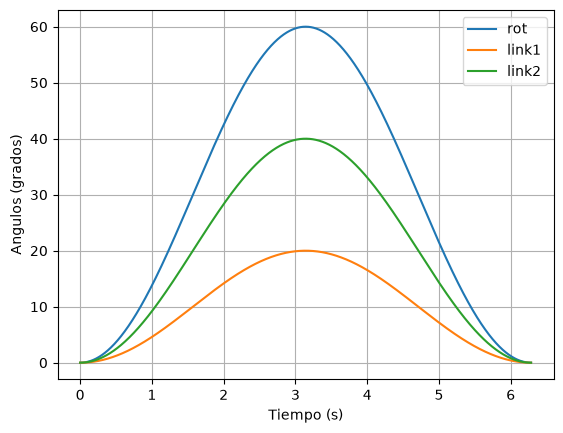

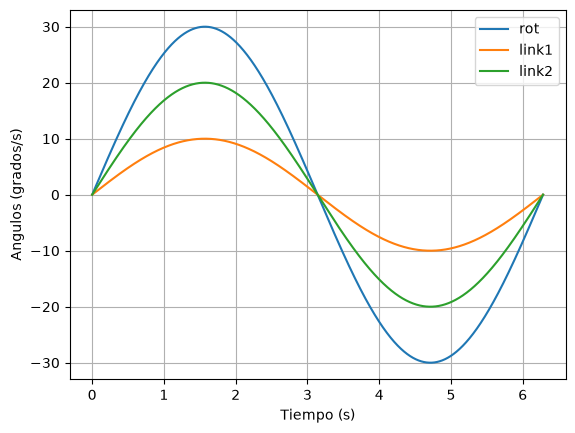

In [16]:
# --- 1. Trajectory Setup & Generation ---
dt = model.opt.timestep
sim_t = 2*np.pi
n_samples = int(sim_t / dt)
t = np.linspace(0, sim_t, n_samples)

q_target = []
qd_target = []
amplitudes = np.deg2rad(np.array([30,10,20]))

for i in t:
    q_target.append(np.sin(i-np.pi/2)*amplitudes+amplitudes)
    qd_target.append(amplitudes*np.cos(i-np.pi/2))

plt.figure()
plt.plot(t,np.rad2deg(q_target))
plt.grid()
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot","link1","link2"])

plt.figure()
plt.plot(t,np.rad2deg(qd_target))
plt.grid()
plt.ylabel("Angulos (grados/s)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot","link1","link2"])

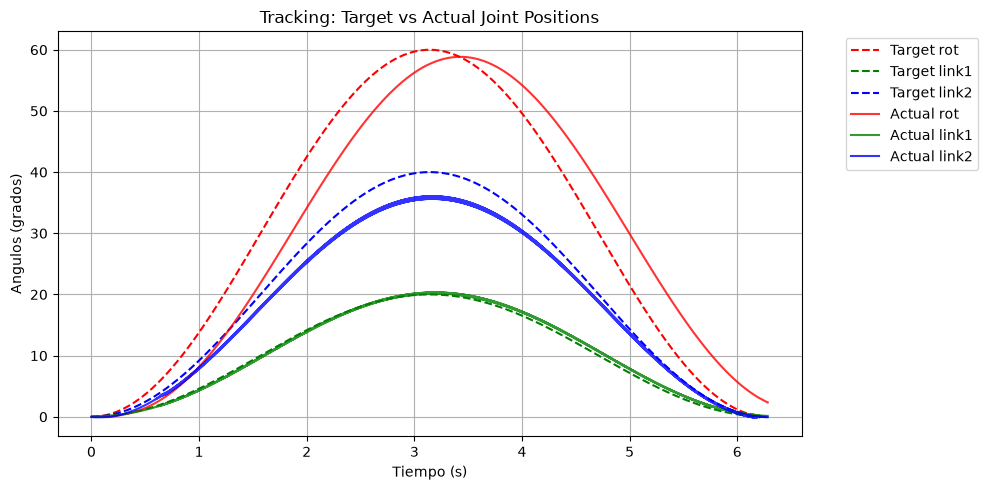

Showing video at 60 FPS...


This browser does not support the video tag.


In [17]:
# --- 1. Trajectory Setup & Generation ---
video_fps = 60                     # Target FPS for the output video

q_target = []
qd_target = []

for i in t:
    q_target.append(np.sin(i - np.pi / 2) * amplitudes + amplitudes)
    qd_target.append(amplitudes * np.cos(i - np.pi / 2))

# Convert to numpy arrays so slicing [:, 0] works in the plot later
q_target = np.array(q_target)
qd_target = np.array(qd_target)

# --- 2. Simulation Setup ---
# Reset to 'home' keyframe initial position
mj.mj_resetDataKeyframe(model, data, model.key("home").id)

renderer = mj.Renderer(model, height=480, width=640)

# --- 3. Run Simulation & Capture Frames ---
qpos_log = []
frames = []

# Keep track of simulation time to render exactly at 60 FPS
last_render_time = data.time - 1.0 

for i in range(n_samples):
    # Set position target to actuators [rot_servo, link1_servo, link2_servo]
    data.ctrl[:3] = q_target[i]
    
    # Step simulation
    mj.mj_step(model, data)
    
    # Log actual joint positions every simulation step (rot, link1, link2)
    qpos_log.append(data.qpos[:3].copy())
    
    # Render frame ONLY if 1/60th of a second has passed in simulation time
    if data.time - last_render_time >= 1.0 / video_fps:
        renderer.update_scene(data, camera="tracking_cam")
        frames.append(renderer.render())
        last_render_time = data.time

qpos_log = np.array(qpos_log)

# --- 4. Plot Target vs Actual qpos ---
plt.figure(figsize=(10, 5))

# Target Joint Angles
plt.plot(t, np.rad2deg(q_target[:, 0]), 'r--', label="Target rot")
plt.plot(t, np.rad2deg(q_target[:, 1]), 'g--', label="Target link1")
plt.plot(t, np.rad2deg(q_target[:, 2]), 'b--', label="Target link2")

# Actual Joint Angles
plt.plot(t, np.rad2deg(qpos_log[:, 0]), 'r-', alpha=0.8, label="Actual rot")
plt.plot(t, np.rad2deg(qpos_log[:, 1]), 'g-', alpha=0.8, label="Actual link1")
plt.plot(t, np.rad2deg(qpos_log[:, 2]), 'b-', alpha=0.8, label="Actual link2")

plt.grid(True)
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.title("Tracking: Target vs Actual Joint Positions")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. Show Video via Mediapy ---
print(f"Showing video at {video_fps} FPS...")
media.show_video(frames, fps=video_fps)
renderer.close()